In [13]:
import numpy as np
import pandas as pd

from etna.datasets import TSDataset, load_dataset
from etna.models import SeasonalMovingAverageModel
from etna.metrics import SMAPE
from etna.analysis import plot_forecast

from src.custom_logger import log_to_mlflow

# SeasonalMovingAverageModel

In [18]:
HORIZON = 8
WINDOW = 5
SEASONALITY = 12
SHIFT = WINDOW * SEASONALITY

In [5]:
smape = SMAPE()

model = SeasonalMovingAverageModel(window=WINDOW, seasonality=SEASONALITY)

## Один временной ряд

In [11]:
ts = load_dataset(name="australian_wine_sales_monthly")

train_ts, test_ts = ts.train_test_split(
    train_start="1980-01-01",
    train_end="1993-12-01",
    test_start="1994-01-01",
    test_end="1994-08-01"
)

# Обучаем на всем историческом контексте
model.fit(train_ts)

future_ts = train_ts.make_future(
    # Горизонт прогноза: сколько пустых строк (NaN) создать в будущем
    future_steps=HORIZON,
    # Контекст: сколько последних строк из истории взять для контекста модели
    tail_steps=model.context_size
)

forecast_ts = model.forecast(
    # Датасет, содержащий историю (контекст) и пустые строки (NaN) под будущее
    ts=future_ts,
    # Размер горизонта: сколько строк с конца таблицы нужно заполнить прогнозом
    prediction_size=HORIZON
)

forecast_ts

segment,main
feature,target
timestamp,
1994-01-01,16431.0
1994-02-01,20391.6
1994-03-01,23784.4
1994-04-01,25668.0
1994-05-01,23306.8
1994-06-01,23036.0
1994-07-01,29253.2
1994-08-01,26689.2


SMAPE: 8.444354755762415


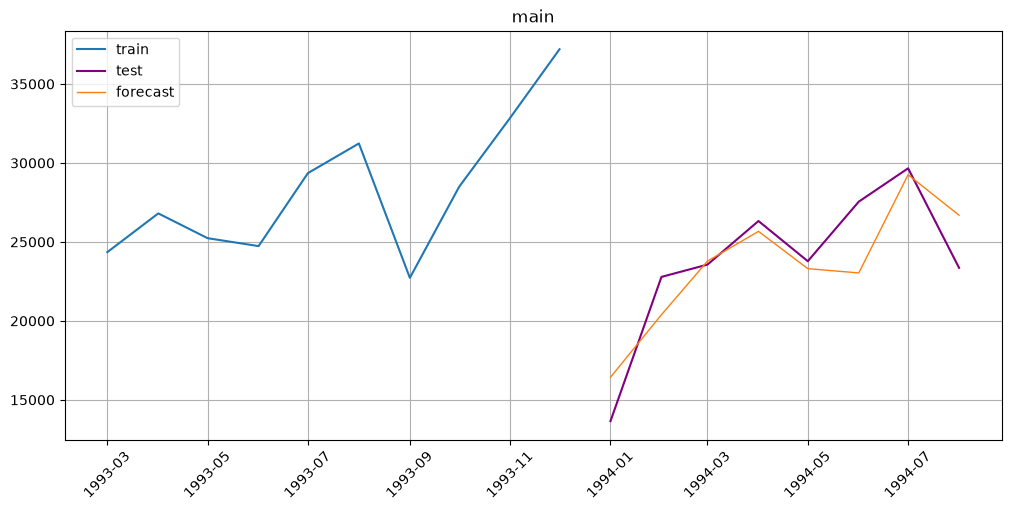

In [14]:
smape_result = smape(y_true=test_ts, y_pred=forecast_ts)
print(f"SMAPE: {smape_result['main']}")

plot_forecast(
    train_ts=train_ts,
    test_ts=test_ts,
    forecast_ts=forecast_ts,
    n_train_samples=10
)

In [16]:
log_to_mlflow(
    model_name="SeasonalMovingAverageModel",
    model_params={
        "window": WINDOW,
        "seasonality": SEASONALITY,
        "lag": 1, # Минимальный лаг (прогнозируем встык к истории)
        "horizon": HORIZON,
        "context_size": model.context_size # Фактическая глубина истории, которая потребовалась модели
    },
    metrics={
        "SMAPE": smape_result['main']
    },
    run_name_suffix="australian_wine_sales_monthly"
)

🏃 View run SeasonalMovingAverageModel_australian_wine_sales_monthly at: http://127.0.0.1:5000/#/experiments/1/runs/cbf2c3758c724b21a5932569bd8859e2
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1

[MLflow] Результаты сохранены в проект 'Study-Etna-Forecasting'
Запуск    : SeasonalMovingAverageModel_australian_wine_sales_monthly
Параметры : {'window': 5, 'seasonality': 12, 'lag': 1, 'horizon': 8, 'context_size': 60}
Метрики   : SMAPE: 8.44


In [21]:
# А теперь воспроизведем полученные результаты руками, что бы понимать.
print(
    f"Ширина окна: {WINDOW}\n"
    f"Сезонность: {SEASONALITY}\n"
    f"Смещение: {SHIFT} (model.context_size)"
)

# Выбираем target из обучающей выборки
targets = train_ts.to_pandas(flatten=True)[0:ts.size()[0] - HORIZON]["target"]

# Выбираем контекст модели из обучающей выборки (tail_steps в future_ts)
series = targets[-SHIFT:].values

# Создаем массив из shifts и горизонта прогноза заполненного нулями
result = np.append(series, np.zeros(HORIZON))
print(f"Заготовка: [{', '.join([f'{x:>.1f}' for x in result])}]\n")

for i in range(SHIFT, len(result)):
    # Номер шага прогноза (от 1 до 8)
    step_num = i - SHIFT + 1

    # Выделяем окно, по которому считаем среднее
    current_window = result[i - SHIFT : i : SEASONALITY]

    # Считаем само среднее
    result[i] = current_window.mean()

    # 1. Делаем красиво
    window_str = ", ".join([f"{x:>.1f}" for x in current_window])

    # 2. Выводим с жестким выравниванием по ширине:
    # {step_num:<2}   - под шаг выделяем 2 символа, прижимаем влево
    # {window_str:<38} - под окно выделяем 38 символов (хватит для 5 чисел с запятыми)
    # {result[i]:<10.2f} - округляем среднее до 2 знаков, выделяем 10 символов
    # {i:<2}          - под позицию выделяем 2 символа
    print(
        f"Шаг {step_num:<2} | "
        f"Окно: [{window_str:<38}] | "
        f"Среднее: {result[i]:<10.2f} | "
        f"Позиция: {i:<2}"
    )

# Забираем финальный прогноз
y_pred = result[-HORIZON:]

# Сезонность в этой модели выступает «щитом», который защищает её от зацикливания на собственных ошибках.
# Но здесь есть важнейший нюанс, который зависит от длины горизонта прогноза (HORIZON).
# Если горизонт прогноза МЕНЬШЕ или РАВЕН сезонности, то все будет работать корректно и модель не будет использовать свои прогнозы для предсказаний.

Ширина окна: 5
Сезонность: 12
Смещение: 60 (model.context_size)
Заготовка: [16991.0, 21109.0, 23740.0, 25552.0, 21752.0, 20294.0, 29009.0, 25500.0, 24166.0, 26960.0, 31222.0, 38641.0, 14672.0, 17543.0, 25453.0, 32683.0, 22449.0, 22316.0, 27595.0, 25451.0, 25421.0, 25288.0, 32568.0, 35110.0, 16052.0, 22146.0, 21198.0, 19543.0, 22084.0, 23816.0, 29961.0, 26773.0, 26635.0, 26972.0, 30207.0, 38687.0, 16974.0, 21697.0, 24179.0, 23757.0, 25013.0, 24019.0, 30345.0, 24488.0, 25156.0, 25650.0, 30923.0, 37240.0, 17466.0, 19463.0, 24352.0, 26805.0, 25236.0, 24735.0, 29356.0, 31234.0, 22724.0, 28496.0, 32857.0, 37198.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

Шаг 1  | Окно: [16991.0, 14672.0, 16052.0, 16974.0, 17466.0] | Среднее: 16431.00   | Позиция: 60
Шаг 2  | Окно: [21109.0, 17543.0, 22146.0, 21697.0, 19463.0] | Среднее: 20391.60   | Позиция: 61
Шаг 3  | Окно: [23740.0, 25453.0, 21198.0, 24179.0, 24352.0] | Среднее: 23784.40   | Позиция: 62
Шаг 4  | Окно: [25552.0, 32683.0, 19543.0, 23757.0, 

In [23]:
# Но если сделать горизонт прогноза БОЛЬШЕ сезонности?
HORIZON = 8 + 6
WINDOW = 5
SEASONALITY = 12
SHIFT = WINDOW * SEASONALITY

# Выбираем target из обучающей выборки
targets = train_ts.to_pandas(flatten=True)[0:ts.size()[0] - HORIZON]["target"]

# Выбираем контекст модели из обучающей выборки (tail_steps в future_ts)
series = targets[-SHIFT:].values

# Создаем массив из shifts и горизонта прогноза заполненного нулями
result = np.append(series, np.zeros(HORIZON))
print(f"Заготовка: [{', '.join([f'{x:>.1f}' for x in result])}]\n")

for i in range(SHIFT, len(result)):
    # Номер шага прогноза (от 1 до 8)
    step_num = i - SHIFT + 1

    # Выделяем окно, по которому считаем среднее
    current_window = result[i - SHIFT : i : SEASONALITY]

    # Считаем само среднее
    result[i] = current_window.mean()

    # 1. Делаем красиво
    window_str = ", ".join([f"{x:>.1f}" for x in current_window])

    # 2. Выводим с жестким выравниванием по ширине:
    # {step_num:<2}   - под шаг выделяем 2 символа, прижимаем влево
    # {window_str:<38} - под окно выделяем 38 символов (хватит для 5 чисел с запятыми)
    # {result[i]:<10.2f} - округляем среднее до 2 знаков, выделяем 10 символов
    # {i:<2}          - под позицию выделяем 2 символа
    print(
        f"Шаг {step_num:<2} | "
        f"Окно: [{window_str:<38}] | "
        f"Среднее: {result[i]:<10.2f} | "
        f"Позиция: {i:<2}"
    )

# на ШАГ13 в базе для расчета среднего используется результат ШАГ1 (30242.6)
# на ШАГ14 в базе для расчета среднего используется результат ШАГ2 (25545.8)

Заготовка: [34303.0, 25517.0, 23494.0, 29095.0, 32903.0, 34379.0, 16991.0, 21109.0, 23740.0, 25552.0, 21752.0, 20294.0, 29009.0, 25500.0, 24166.0, 26960.0, 31222.0, 38641.0, 14672.0, 17543.0, 25453.0, 32683.0, 22449.0, 22316.0, 27595.0, 25451.0, 25421.0, 25288.0, 32568.0, 35110.0, 16052.0, 22146.0, 21198.0, 19543.0, 22084.0, 23816.0, 29961.0, 26773.0, 26635.0, 26972.0, 30207.0, 38687.0, 16974.0, 21697.0, 24179.0, 23757.0, 25013.0, 24019.0, 30345.0, 24488.0, 25156.0, 25650.0, 30923.0, 37240.0, 17466.0, 19463.0, 24352.0, 26805.0, 25236.0, 24735.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

Шаг 1  | Окно: [34303.0, 29009.0, 27595.0, 29961.0, 30345.0] | Среднее: 30242.60   | Позиция: 60
Шаг 2  | Окно: [25517.0, 25500.0, 25451.0, 26773.0, 24488.0] | Среднее: 25545.80   | Позиция: 61
Шаг 3  | Окно: [23494.0, 24166.0, 25421.0, 26635.0, 25156.0] | Среднее: 24974.40   | Позиция: 62
Шаг 4  | Окно: [29095.0, 26960.0, 25288.0, 26972.0, 25650.0] | Среднее: 26793.00   | П

## Несколько временных рядов

In [24]:
df = pd.read_csv("data/example.csv")
multi_ts = TSDataset(df=df, freq="D")

HORIZON_MULTI = 7

train_ts, test_ts = multi_ts.train_test_split(
    train_start="2019-01-01",
    train_end="2019-12-24",
    test_start="2019-12-25",
    test_end="2019-12-31"
)

In [31]:
model = SeasonalMovingAverageModel(window=5, seasonality=7)

model.fit(train_ts)

future_ts = train_ts.make_future(
    # Количество меток, которые хотим предсказать
    future_steps=HORIZON_MULTI,
    # Количество меток, которые используем для прогноза (контекст модели)
    tail_steps=model.context_size
)

forecast_ts = model.forecast(
    # Заготовка под прогнозы с контекстом прошлого
    ts=future_ts,
    # Сколько меток с КОНЦА надо отсчитать, чтобы разделить датафрейм на две части: до/после HORIZON
    prediction_size=HORIZON_MULTI
)

print(f"SMAPE: {smape(y_true=test_ts, y_pred=forecast_ts)}")
forecast_ts

SMAPE: {'segment_a': 12.75413973441905, 'segment_b': 13.875095600615348, 'segment_c': 24.577172132520488, 'segment_d': 16.2135368848414}


segment,segment_a,segment_b,segment_c,segment_d
feature,target,target,target,target
timestamp,,,,
2019-12-25,603.2,267.2,206.4,976.2
2019-12-26,583.2,259.2,208.8,942.4
2019-12-27,559.6,254.0,231.2,894.4
2019-12-28,478.2,214.8,188.0,737.8
2019-12-29,481.8,209.6,178.8,717.4
2019-12-30,615.6,273.4,223.2,980.6
2019-12-31,618.4,274.4,224.0,1007.2


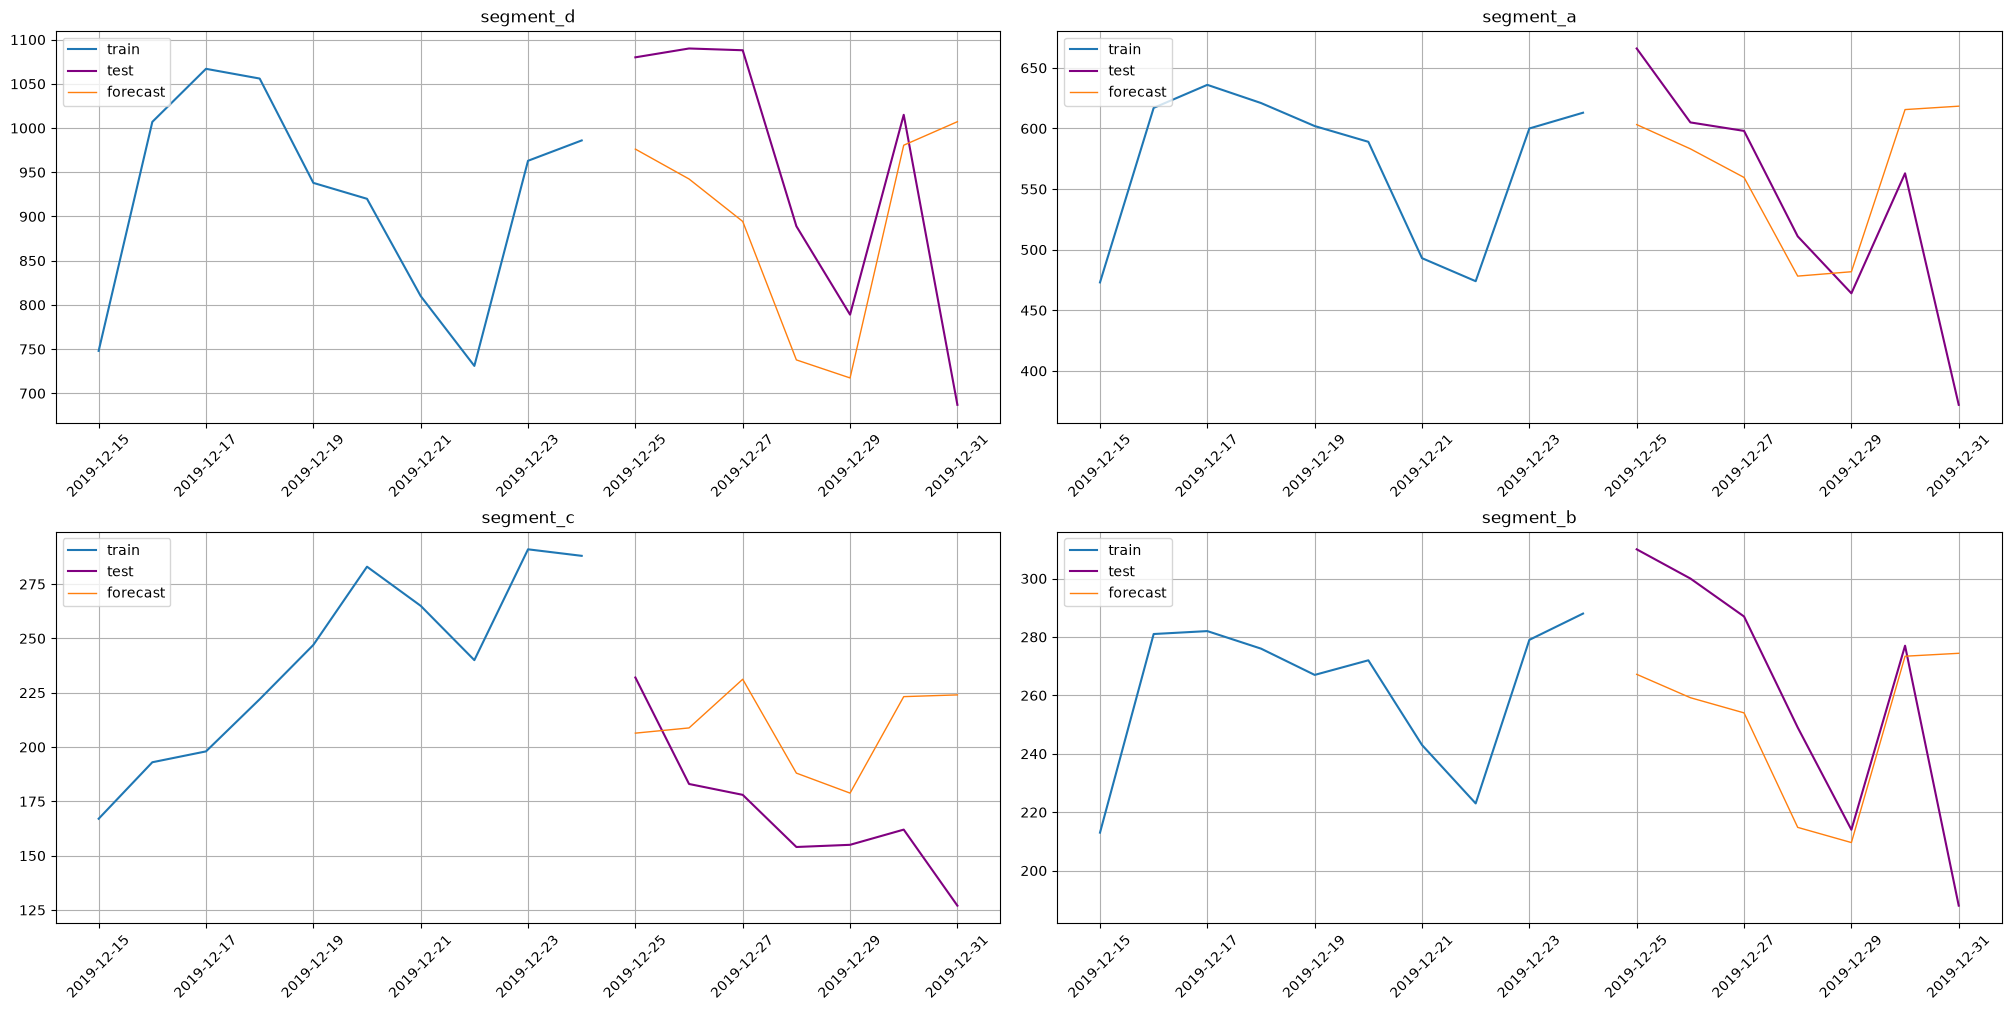

In [32]:
plot_forecast(
    train_ts=train_ts,
    test_ts=test_ts,
    forecast_ts=forecast_ts,
    n_train_samples=10
)